<a href="https://colab.research.google.com/github/yesufma/solar-challenge-week1/blob/Main/Togo_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup & Data Loading

In [2]:
# Install required libraries (if needed)
!pip install windrose
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from windrose import WindroseAxes

# Mount Google Drive (for Colab)
from google.colab import drive
drive.mount('/content/drive')

# Load data (replace path)
file_path = '/content/drive/MyDrive/Solar_Project/data/togo.csv'
df = pd.read_csv(file_path)

Mounted at /content/drive


#Data Profiling

In [3]:
# Summary statistics for numeric columns
print("Summary Statistics:")
print(df.describe(include=np.number))

# Missing values analysis
missing_values = df.isna().sum()
missing_percent = (missing_values / len(df)) * 100
print("\nMissing Values (%):")
print(missing_percent.round(2))
high_missing_cols = missing_percent[missing_percent > 5].index.tolist()
print("\nColumns with >5% missing values:", high_missing_cols)

Summary Statistics:
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      230.555040     151.258469     116.444352     226.144375   
std       322.532347     250.956962     156.520714     317.346938   
min       -12.700000       0.000000       0.000000       0.000000   
25%        -2.200000       0.000000       0.000000       0.000000   
50%         2.100000       0.000000       2.500000       4.400000   
75%       442.400000     246.400000     215.700000     422.525000   
max      1424.000000    1004.500000     805.700000    1380.000000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      219.568588      27.751788      55.013160       2.368093   
std       307.932510       4.758023      28.778732       1.462668   
min         0.000000      14.900000       3.300000       0.000000   
25%         0

#Data Cleaning

In [4]:
# --- Data Cleaning Pipeline ---
# 1. Remove non-essential columns
df_clean = df.drop(columns=['Comments']).copy()

# 2. Handle negative values in solar metrics
solar_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB']
df_clean[solar_cols] = df_clean[solar_cols].clip(lower=0)

# 3. Outlier removal using Z-scores
outlier_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = stats.zscore(df_clean[outlier_cols])
outliers = (abs(z_scores) > 3).any(axis=1)
df_clean = df_clean[~outliers]
print(f"Removed {outliers.sum()} outliers.\n")

# 4. Missing value imputation
key_cols = ['GHI', 'DNI', 'Tamb', 'RH']
df_clean[key_cols] = df_clean[key_cols].fillna(df_clean[key_cols].median())

# --- Generate Summary Table ---
# Calculate statistics
summary_stats = df_clean[['GHI', 'RH']].agg(['mean', 'max', 'std']).round(2)

# Format table
formatted_table = summary_stats.T.reset_index()
formatted_table.columns = ['Feature', 'Mean', 'Max', 'Std']

# Display results
print("Table 4.1: Summary Statistics for Togo")
print(formatted_table.to_markdown(index=False))

Removed 9257 outliers.

Table 4.1: Summary Statistics for Togo
| Feature   |   Mean |    Max |    Std |
|:----------|-------:|-------:|-------:|
| GHI       | 225.03 | 1196   | 316.45 |
| RH        |  55.18 |   99.8 |  28.7  |


#Time Series Analysis

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


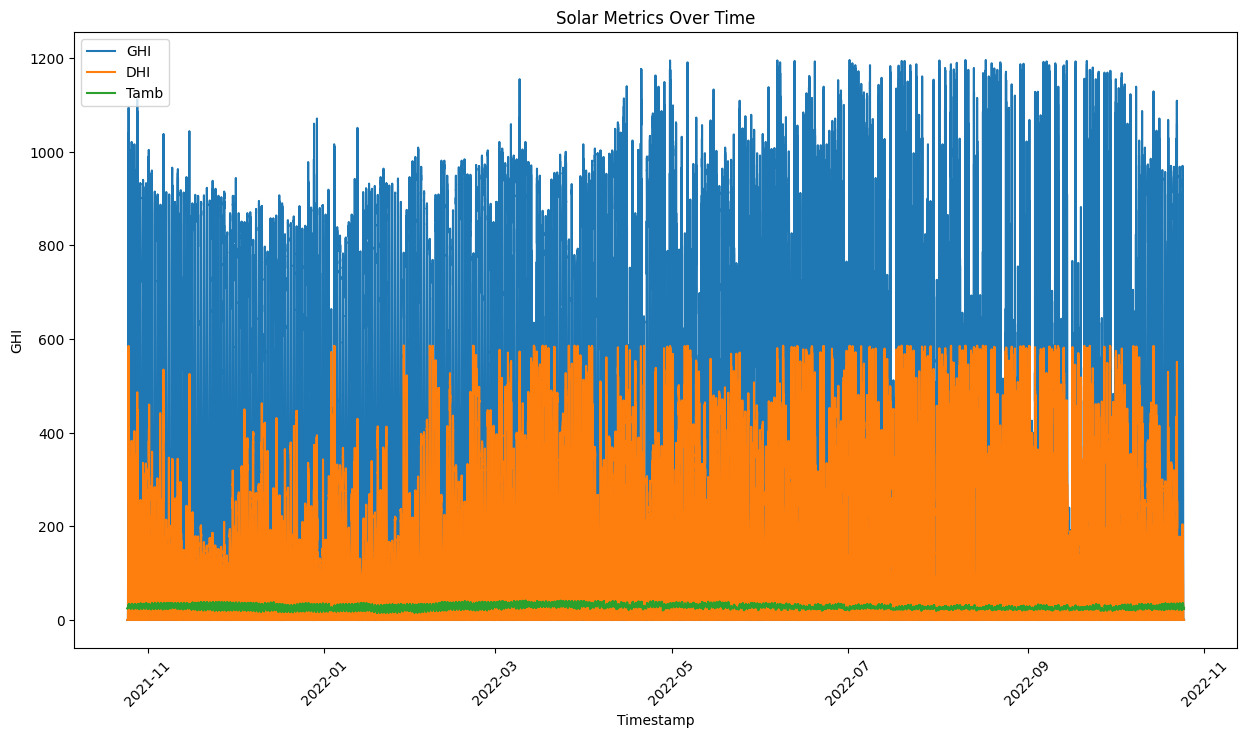

In [ ]:
# Convert Timestamp to datetime
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

# Plot GHI, DHI, Tamb over time
variables = ['GHI', 'DHI', 'Tamb']
plt.figure(figsize=(15, 8))
for var in variables:
    sns.lineplot(x='Timestamp', y=var, data=df_clean, label=var)
plt.title('Solar Metrics Over Time')
plt.xticks(rotation=45)
plt.show()

#Cleaning Impact Analysis

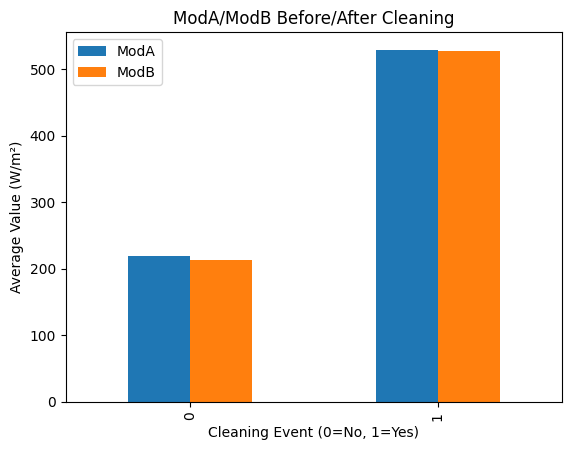

In [ ]:
# Group by 'Cleaning' and plot ModA/ModB
cleaning_groups = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()
cleaning_groups.plot(kind='bar', title='ModA/ModB Before/After Cleaning')
plt.xlabel('Cleaning Event (0=No, 1=Yes)')
plt.ylabel('Average Value (W/m²)')
plt.show()

#Correlation & Relationships

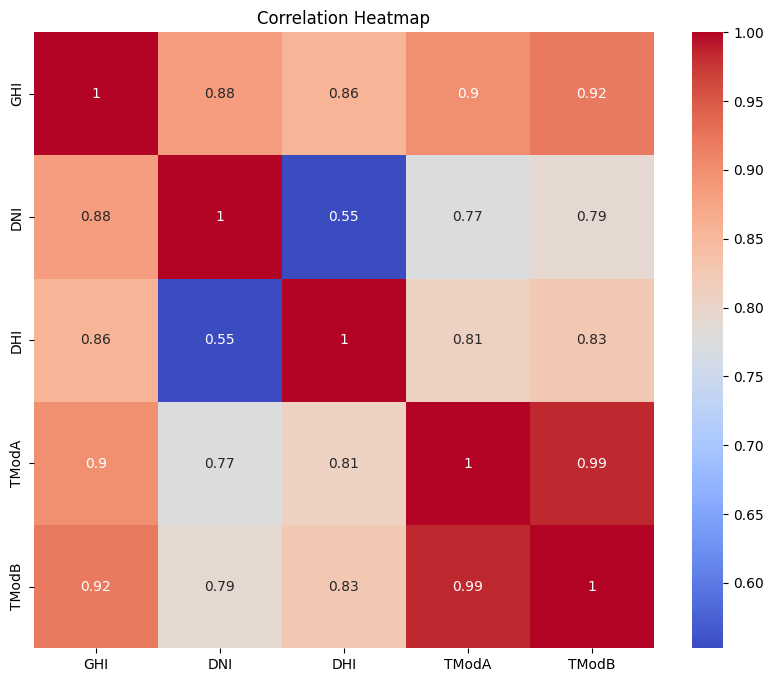

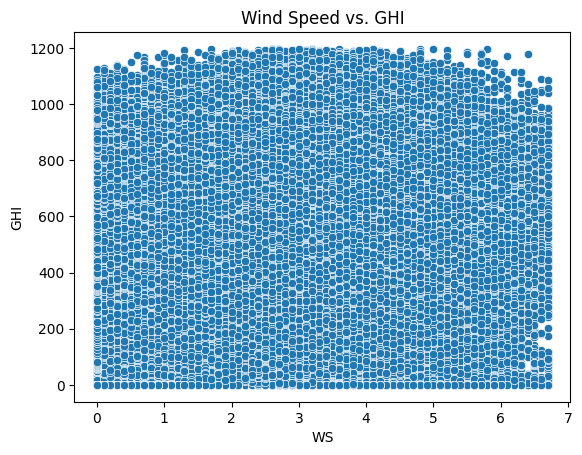

In [ ]:
# Heatmap
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
corr_matrix = df_clean[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Scatter plots
sns.scatterplot(x='WS', y='GHI', data=df_clean)
plt.title('Wind Speed vs. GHI')
plt.show()

#Wind & Distribution Analysis

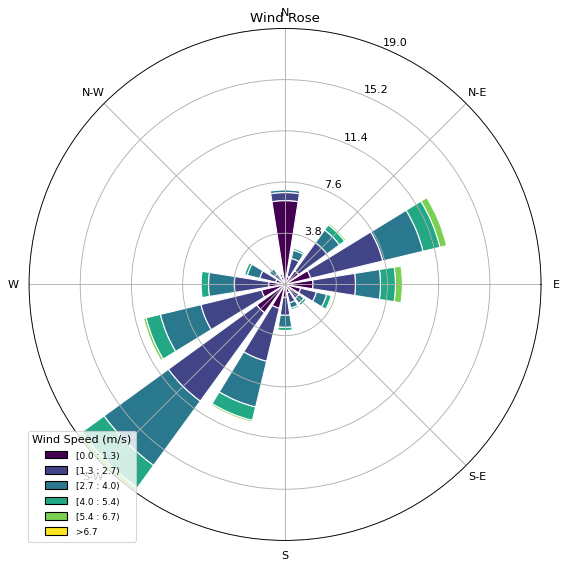

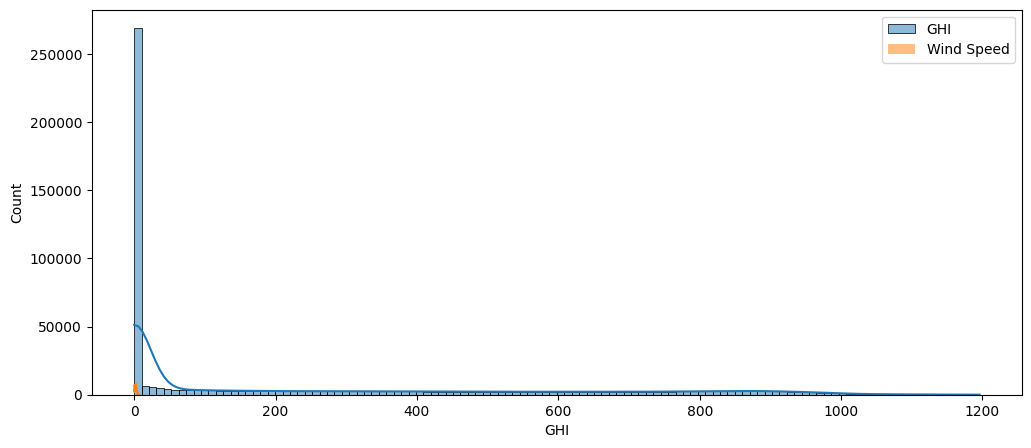

In [ ]:
# Wind Rose
ax = WindroseAxes.from_ax()
ax.bar(df_clean['WD'], df_clean['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_legend(title='Wind Speed (m/s)')
plt.title('Wind Rose')
plt.show()

# Histograms
plt.figure(figsize=(12, 5))
sns.histplot(df_clean['GHI'], kde=True, label='GHI')
sns.histplot(df_clean['WS'], kde=True, label='Wind Speed')
plt.legend()
plt.show()

#Temperature Impact

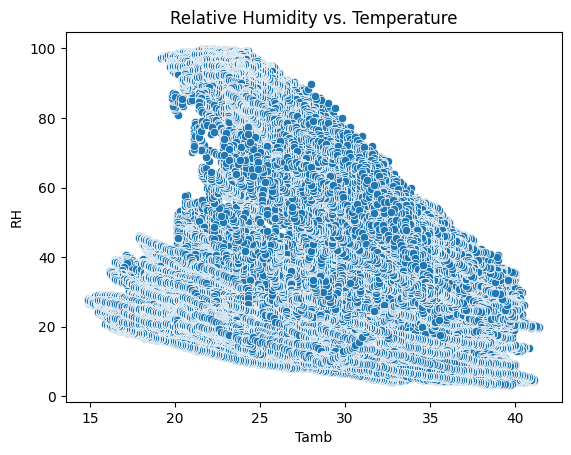

In [ ]:
# RH vs. Tamb
sns.scatterplot(x='Tamb', y='RH', data=df_clean)
plt.title('Relative Humidity vs. Temperature')
plt.show()

#Bubble Chart

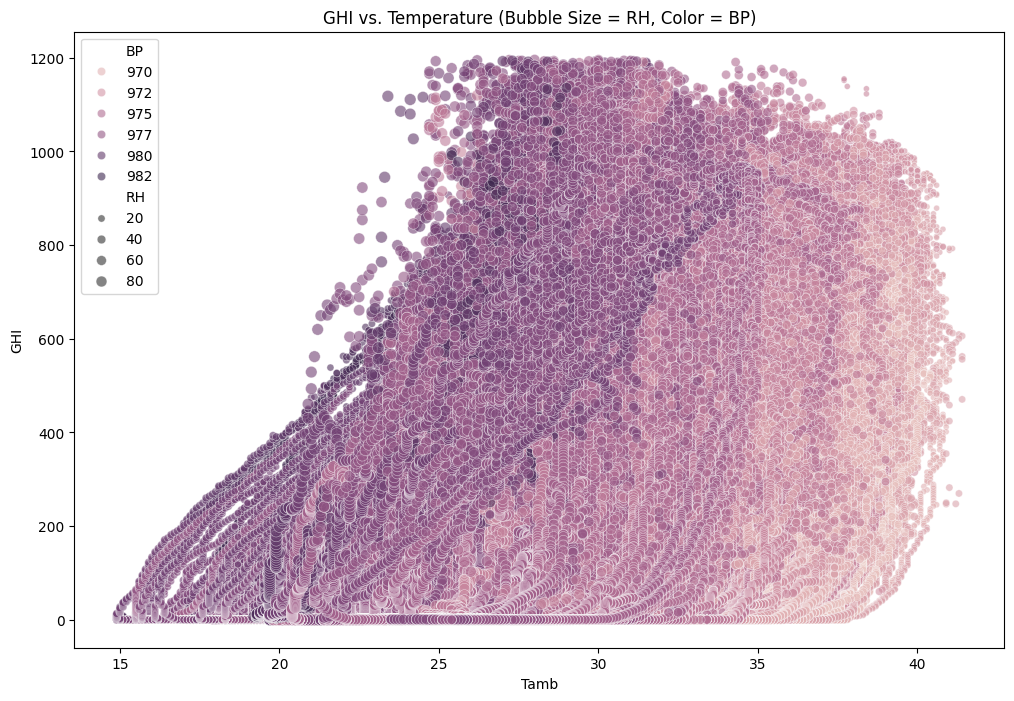

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Tamb', y='GHI', size='RH', hue='BP', data=df_clean, alpha=0.6)
plt.title('GHI vs. Temperature (Bubble Size = RH, Color = BP)')
plt.show()

#Export Cleaned Data

In [ ]:
# Save to data/ folder
import os
os.makedirs('data', exist_ok=True)
df_clean.to_csv('/content/drive/MyDrive/Solar_Project/data/togo_clean.csv', index=False)
print("Cleaned data saved to data/togo_clean.csv")

Cleaned data saved to data/togo_clean.csv
